## 1) Installs

In [1]:
import sys
!{sys.executable} -m pip install tqdm rembg onnxruntime --quiet
!{sys.executable} -m pip install ipywidgets --quiet
!{sys.executable} -m pip install rembg[gpu] --quiet

## 2) Imports

In [2]:
import os, random, time, json, pickle
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 3) Reproducibility + Device

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

if DEVICE == "cuda":
    _t = torch.ones(1).cuda()
    print("CUDA tensor device:", _t.device)
    del _t

DEVICE: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
CUDA tensor device: cuda:0


## 4) Paths + Hyperparameters

In [4]:
# Paths
ALPHABET_ROOT = os.path.join("American Sign Language Alphabet","asl_alphabet_train", "asl_alphabet_train")
DIGITS_ROOT   = os.path.join("American Sign Language Digits Dataset")
SEG_ROOT      = os.path.join("asl_alphabet_segmented")
OUT_DIR       = "runs_asl36_final"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(SEG_ROOT, exist_ok=True)

# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 3

# Split fractions
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# DataLoader 
NUM_WORKERS = 0
PREFETCH = None

print("Alphabet root exists?", os.path.isdir(ALPHABET_ROOT))
print("Digits root exists?", os.path.isdir(DIGITS_ROOT))
print("Output dir:", OUT_DIR)

Alphabet root exists? True
Digits root exists? True
Output dir: runs_asl36_final


## 5) Class Mapping

In [5]:
letters = [chr(c) for c in range(ord("A"), ord("Z")+1)]
digits = [str(d) for d in range(10)]
class_names = letters + digits
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print("Classes:", class_names)
print("Total classes:", len(class_names))

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Total classes: 36


## 6) File Collection Helpers

In [6]:
def list_images(folder):
    exts = (".png", ".jpg", ".jpeg", ".bmp", ".webp")
    return [
        os.path.join(folder, fn)
        for fn in os.listdir(folder)
        if fn.lower().endswith(exts)
    ]

def collect_alphabet_samples(root):
    samples = []
    for L in letters:
        cdir = os.path.join(root, L)
        if not os.path.isdir(cdir):
            raise FileNotFoundError(f"Missing alphabet folder: {cdir}")
        for p in list_images(cdir):
            samples.append((p, class_to_idx[L]))
    return samples

def collect_digit_samples(root):
    samples = []
    for d in digits:
        d_root    = os.path.join(root, d)
        input_dir = os.path.join(d_root, f"Input Images - Sign {d}")
        if not os.path.isdir(input_dir):
            raise FileNotFoundError(f"Missing: {input_dir}")
        for p in list_images(input_dir):
            samples.append((p, class_to_idx[d]))
    return samples

alphabet_samples = collect_alphabet_samples(ALPHABET_ROOT)
digit_samples = collect_digit_samples(DIGITS_ROOT)
all_samples = alphabet_samples + digit_samples

print(f"Alphabet: {len(alphabet_samples)}")
print(f"Digits: {len(digit_samples)}")
print(f"Total: {len(all_samples)}")

Alphabet: 78000
Digits: 5000
Total: 83000


## 7) Training, Validation and Testing Split

In [7]:
ys = np.array([y for _, y in all_samples])

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=SEED)
trainval_idx, test_idx = next(sss1.split(np.zeros(len(ys)), ys))

trainval_samples = [all_samples[i] for i in trainval_idx]
test_samples = [all_samples[i] for i in test_idx]

ys_trainval = np.array([y for _, y in trainval_samples])
val_rel = VAL_FRAC / (TRAIN_FRAC + VAL_FRAC)

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_rel, random_state=SEED)
train_idx, val_idx = next(sss2.split(np.zeros(len(ys_trainval)), ys_trainval))

train_samples = [trainval_samples[i] for i in train_idx]
val_samples = [trainval_samples[i] for i in val_idx]

print(f"Train: {len(train_samples)} ({len(train_samples)/len(all_samples)*100:.1f}%)")
print(f"Val: {len(val_samples)} ({len(val_samples)/len(all_samples)*100:.1f}%)")
print(f"Test: {len(test_samples)} ({len(test_samples)/len(all_samples)*100:.1f}%)")

Train: 58100 (70.0%)
Val: 12450 (15.0%)
Test: 12450 (15.0%)


## 8) Transforms

In [8]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),
])

test_tf = val_tf

## 9) Dataset Classes

In [9]:
class ASLDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, y = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), y

## 10) DataLoader Builder

In [10]:
def make_loaders(train_s, val_s, test_s):
    pin = (DEVICE == "cuda")

    train_loader = DataLoader(
        ASLDataset(train_s, train_tf),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin,
        persistent_workers=False,
        prefetch_factor=PREFETCH,
    )
    val_loader = DataLoader(
        ASLDataset(val_s, val_tf),
        batch_size=BATCH_SIZE * 2,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin,
        persistent_workers=False,
        prefetch_factor=PREFETCH,
    )
    test_loader = DataLoader(
        ASLDataset(test_s, test_tf),
        batch_size=BATCH_SIZE * 2,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin,
        persistent_workers=False,
        prefetch_factor=PREFETCH,
    )
    return train_loader, val_loader, test_loader

## 11) Model Builder

In [11]:
def build_model(name):
    n = len(class_names)

    if name == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, n)

    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, n)

    elif name == "mobilenet_v2":
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, n)
    
    else:
        raise ValueError(f"Unknown model: {name}")

    return m.to(DEVICE)

## 12) Evaluate Function

In [12]:
def evaluate(model, loader, split_name=""):
    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
                logits = model(xb)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(yb.cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    f1  = f1_score(all_true, all_preds, average="macro")

    if split_name:
        print(f" {split_name:10s} → acc={acc:.4f} | macroF1={f1:.4f}")

    return acc, f1, all_preds, all_true

## 13) Training Function

In [13]:
def train_model(name, train_samples, val_samples, tag=""):
    print(f"\n{'='*60}")
    print(f"Training: {name}{tag}")
    print(f"{'='*60}")

    train_loader, val_loader, test_loader = make_loaders(
        train_samples, val_samples, test_samples
    )

    model = build_model(name)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS
    )
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

    best_val_acc = -1.0
    best_path = os.path.join(OUT_DIR, f"best_{name}{tag}.pt")
    history = {
        "train_loss": [],
        "train_acc":  [],
        "val_acc":    [],
        "val_f1":     [],
        "test_acc":   [],
        "test_f1":    [],
        "epoch_time": []
    }

    epochs_no_improve = 0
    stopped_early = False

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_losses = []
        train_correct = 0
        train_total = 0
        t0 = time.time()

        pbar = tqdm(train_loader,
                    desc=f"[{name}{tag}] Epoch {epoch:02d}/{EPOCHS} [train]",leave=False)

        for xb, yb in pbar:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            # Training accuracy
            preds = torch.argmax(logits, dim=1)
            train_correct += (preds == yb).sum().item()
            train_total += yb.size(0)

            train_losses.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        # Per epoch metrics
        train_acc = train_correct / train_total
        val_acc, val_f1, _, _ = evaluate(model, val_loader)
        test_acc, test_f1, _, _ = evaluate(model, test_loader)
        elapsed = time.time() - t0
        scheduler.step()

        history["train_loss"].append(np.mean(train_losses))
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["test_acc"].append(test_acc)
        history["test_f1"].append(test_f1)
        history["epoch_time"].append(elapsed)

        print(
            f"[{name}{tag}] Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={np.mean(train_losses):.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"test_acc={test_acc:.4f} | "
            f"test_f1={test_f1:.4f} | "
            f"lr={scheduler.get_last_lr()[0]:.2e} | "
            f"time={elapsed:.1f}s"
        )

        if val_acc > best_val_acc:
            best_val_acc      = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_path)
            print(f" New best saved ({val_acc:.4f})")
        else:
            epochs_no_improve += 1
            print(f"  No improvement ({epochs_no_improve}/{PATIENCE})")

        if epochs_no_improve >= PATIENCE:
            print(f"\n Early stopping triggered at epoch {epoch}")
            print(f" No improvement for {PATIENCE} consecutive epochs")
            stopped_early = True
            break

    if not stopped_early:
        print(f"\n  Completed all {EPOCHS} epochs")

    print(f"\nBest val acc for {name}{tag}: {best_val_acc:.4f}")
    print(f"Saved to: {best_path}")

    hist_path = os.path.join(OUT_DIR, f"history_{name}{tag}.json")
    with open(hist_path, "w") as f:
        json.dump(history, f, indent=2)

    return history, best_path

## 14) Base Models Training

In [14]:
# ResNet18 + EfficientNet-B0 only

histories    = {}
model_paths  = {}

histories["resnet18"], model_paths["resnet18"] = train_model(
    "resnet18", train_samples, val_samples
)

histories["efficientnet_b0"], model_paths["efficientnet_b0"] = train_model(
    "efficientnet_b0", train_samples, val_samples
)

histories["mobilenet_v2"], model_paths["mobilenet_v2"] = train_model(
    "mobilenet_v2", train_samples, val_samples
)

print("\nAll models trained.")


Training: resnet18


[resnet18] Epoch 01/10 [train]:   0%|          | 0/454 [00:00<?, ?it/s]

[resnet18] Epoch 01/10 | train_loss=0.3368 | train_acc=0.9328 | val_acc=0.9970 | val_f1=0.9909 | test_acc=0.9971 | test_f1=0.9928 | lr=9.76e-05 | time=499.5s
 New best saved (0.9970)


[resnet18] Epoch 02/10 [train]:   0%|          | 0/454 [00:00<?, ?it/s]

[resnet18] Epoch 02/10 | train_loss=0.0228 | train_acc=0.9953 | val_acc=0.9994 | val_f1=0.9983 | test_acc=0.9991 | test_f1=0.9969 | lr=9.05e-05 | time=498.3s
 New best saved (0.9994)


...

[mobilenet_v2] Epoch 06/10 | train_loss=0.0077 | train_acc=0.9981 | val_acc=1.0000 | val_f1=1.0000 | test_acc=0.9999 | test_f1=0.9999 | lr=3.45e-05 | time=528.9s
  No improvement (1/3)


[mobilenet_v2] Epoch 07/10 [train]:   0%|          | 0/454 [00:00<?, ?it/s]

[mobilenet_v2] Epoch 07/10 | train_loss=0.0076 | train_acc=0.9981 | val_acc=1.0000 | val_f1=1.0000 | test_acc=1.0000 | test_f1=1.0000 | lr=2.06e-05 | time=528.0s
  No improvement (2/3)


[mobilenet_v2] Epoch 08/10 [train]:   0%|          | 0/454 [00:00<?, ?it/s]

[mobilenet_v2] Epoch 08/10 | train_loss=0.0058 | train_acc=0.9986 | val_acc=1.0000 | val_f1=1.0000 | test_acc=1.0000 | test_f1=1.0000 | lr=9.55e-06 | time=527.6s
  No improvement (3/3)

 Early stopping triggered at epoch 8
 No improvement for 3 consecutive epochs

Best val acc for mobilenet_v2: 1.0000
Saved to: runs_asl36_final\best_mobilenet_v2.pt

All models trained.


## 15) Plot Training Curves

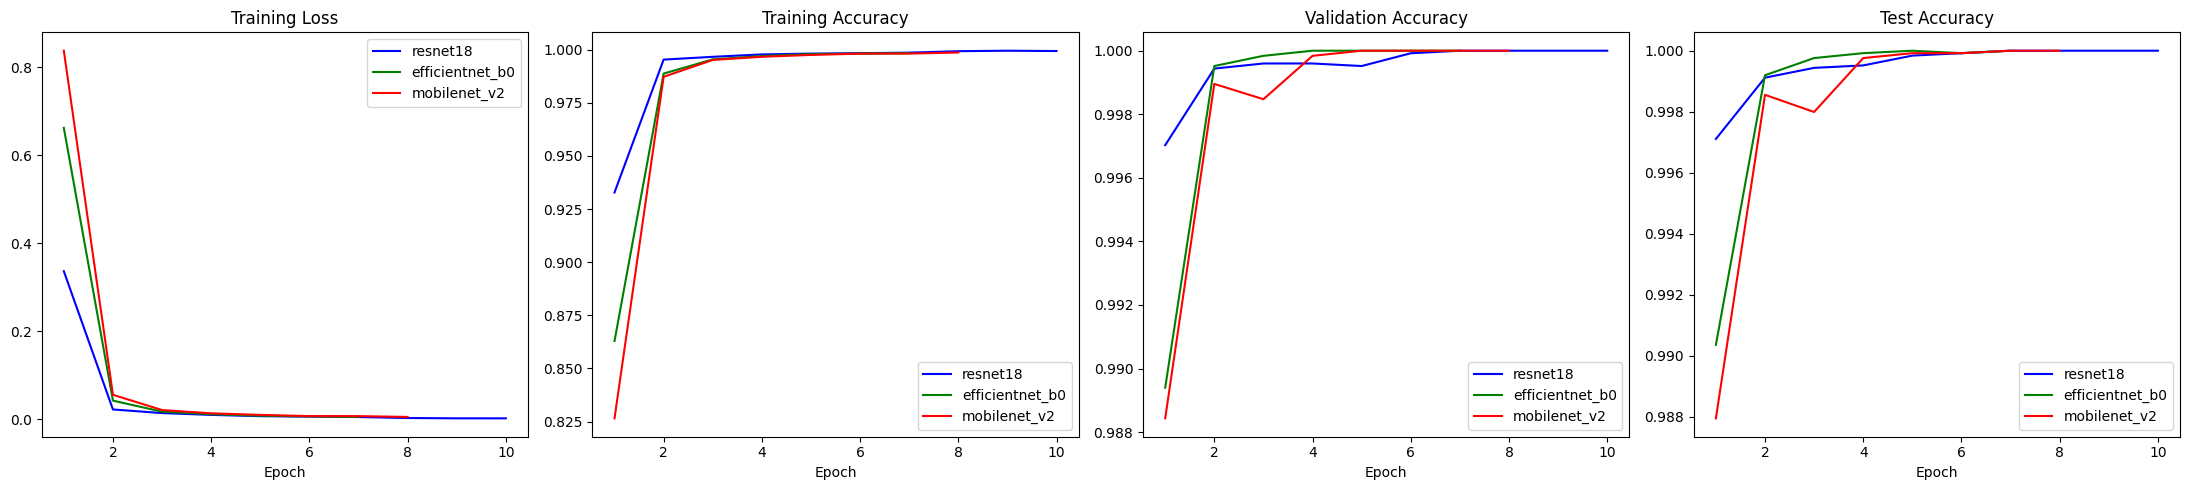

Saved: training_curves.png


In [15]:
def plot_training_curves(histories):
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    colors = {"resnet18": "blue", "efficientnet_b0": "green", "mobilenet_v2": "red"}

    for name, hist in histories.items():
        epochs = range(1, len(hist["train_loss"]) + 1)
        axes[0].plot(epochs, hist["train_loss"], label=name, color=colors[name])
        axes[1].plot(epochs, hist["train_acc"], label=name, color=colors[name])
        axes[2].plot(epochs, hist["val_acc"], label=name, color=colors[name])
        axes[3].plot(epochs, hist["test_acc"], label=name, color=colors[name])

    axes[0].set_title("Training Loss")
    axes[1].set_title("Training Accuracy")
    axes[2].set_title("Validation Accuracy")
    axes[3].set_title("Test Accuracy")

    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=150)
    plt.show()
    print("Saved: training_curves.png")

plot_training_curves(histories)

## 16) Test Set Evaluation for the 3 Models

In [16]:
_, _, test_loader = make_loaders(train_samples, val_samples, test_samples)

test_results = {}

print("="*60)
print("FINAL TEST SET EVALUATION")
print("="*60)

for name, path in model_paths.items():
    model = build_model(name)
    model.load_state_dict(torch.load(path, map_location=DEVICE, weights_only=True))
    acc, f1, preds, true = evaluate(model, test_loader, split_name=name)
    test_results[name] = {"test_acc": acc, "test_f1": f1}

with open(os.path.join(OUT_DIR, "test_results.json"), "w") as f:
    json.dump(test_results, f, indent=2)
print("\nTest results saved.")

FINAL TEST SET EVALUATION
 resnet18   → acc=1.0000 | macroF1=1.0000
 efficientnet_b0 → acc=0.9999 | macroF1=0.9999
 mobilenet_v2 → acc=0.9999 | macroF1=0.9999

Test results saved.


## 17) Confusion Matrix of Best Model

Best model: resnet18


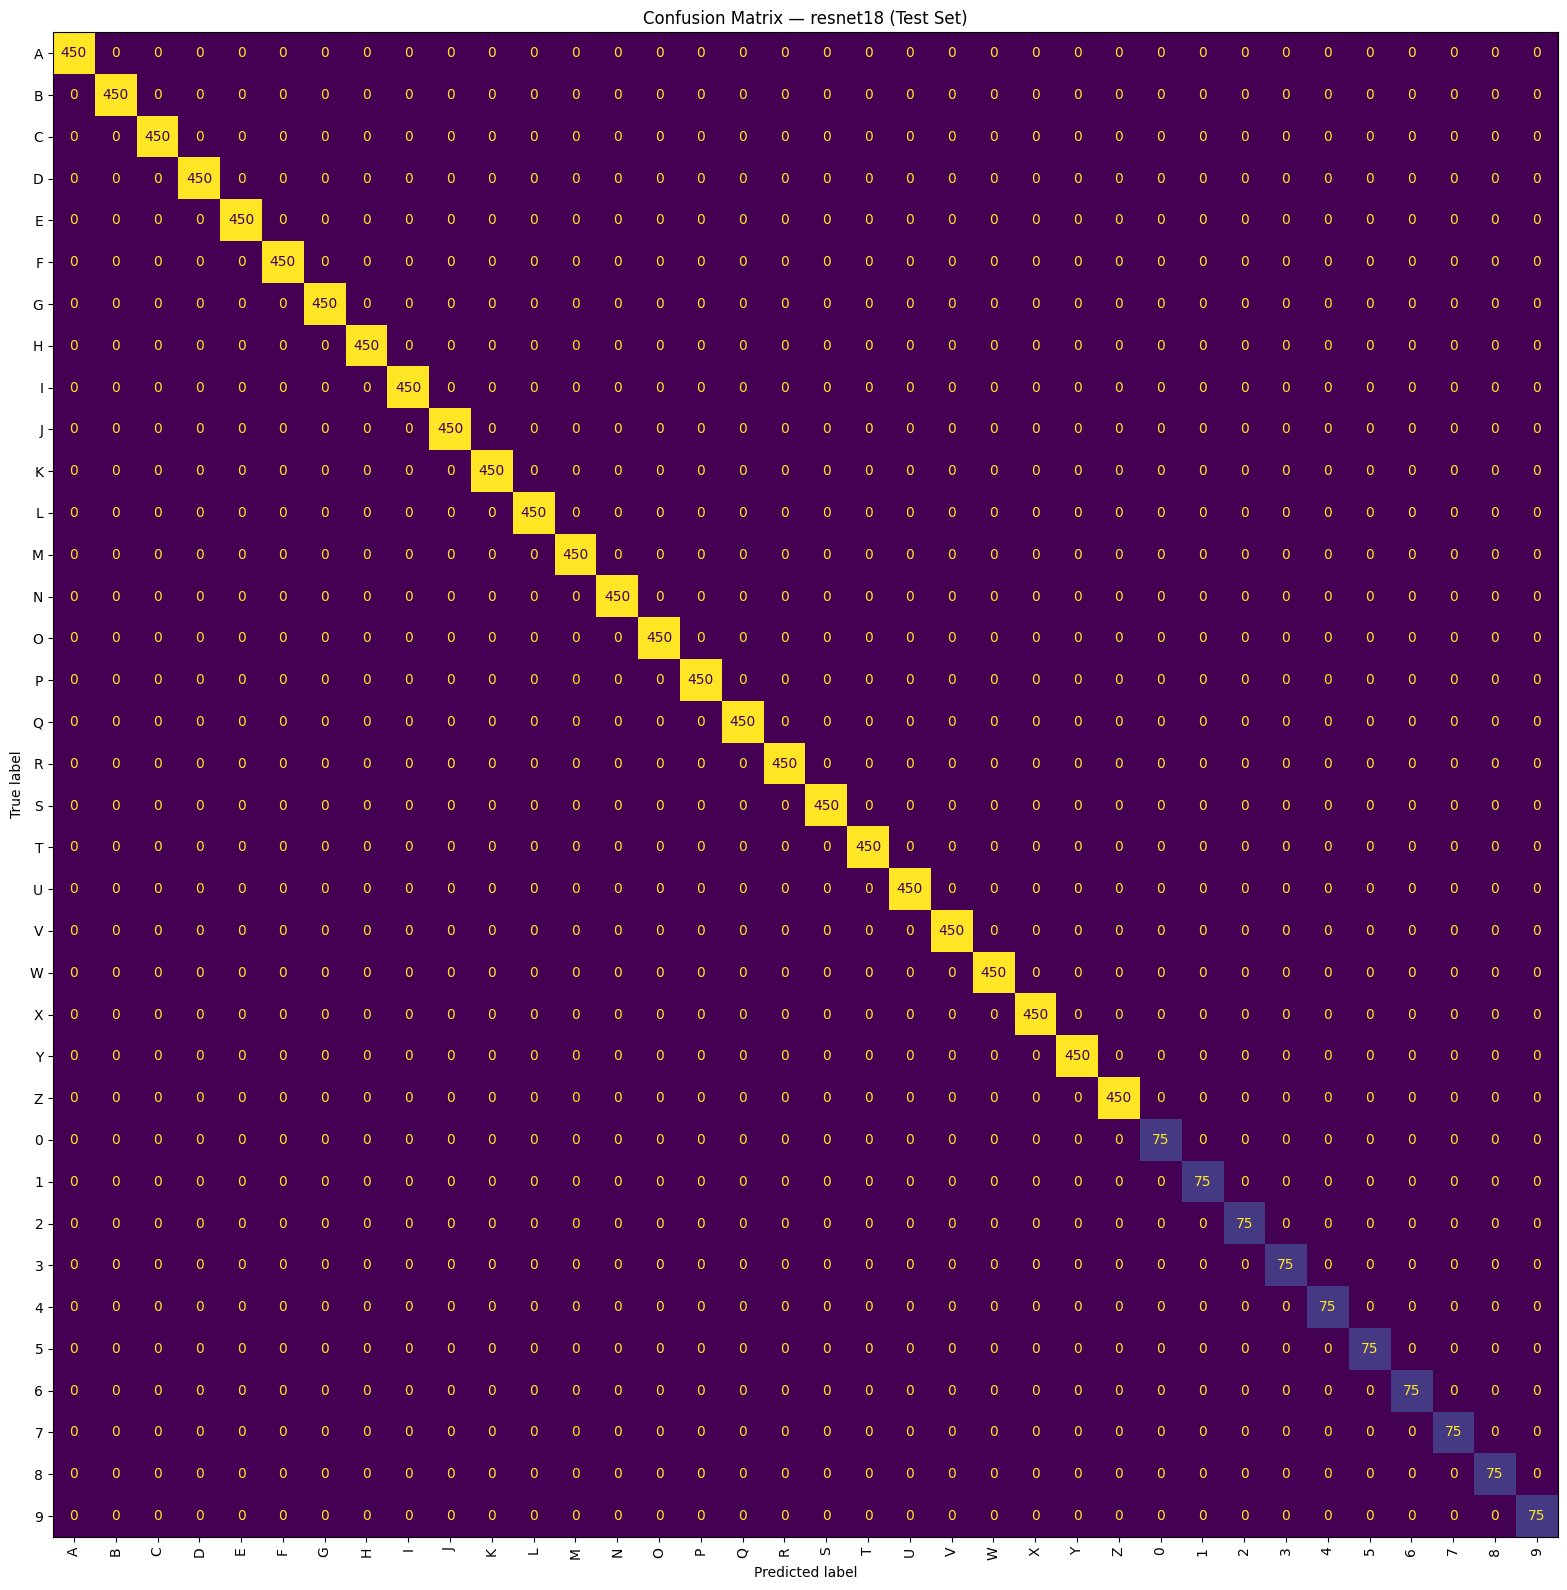

Saved: confusion_matrix_test.png


In [17]:
best_model_name = max(test_results, key=lambda k: test_results[k]["test_acc"])
print(f"Best model: {best_model_name}")

model = build_model(best_model_name)
model.load_state_dict(torch.load(
    model_paths[best_model_name], map_location=DEVICE, weights_only=True
))

_, _, preds, true = evaluate(model, test_loader)

cm   = confusion_matrix(true, preds, labels=list(range(len(class_names))))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(16, 16))
disp.plot(ax=ax, xticks_rotation="vertical", colorbar=False)
plt.title(f"Confusion Matrix — {best_model_name} (Test Set)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix_test.png"), dpi=200)
plt.show()
print("Saved: confusion_matrix_test.png")

## 18) Robustness Experiment

In [18]:
def robustness_test(model_name, model_path, test_samples):
    perturbations = {
        "clean": val_tf,
        "blur": transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.GaussianBlur(kernel_size=11, sigma=(2.0, 5.0)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ]),
        "brightness": transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ColorJitter(brightness=2.0),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ]),
        "contrast": transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ColorJitter(contrast=3.0),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ]),
        "noise": transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Lambda(lambda x: (x + 0.1 * torch.randn_like(x)).clamp(0,1)),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ]),
    }

    model = build_model(model_name)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))

    results = {}
    for p_name, tf in perturbations.items():
        loader = DataLoader(
            ASLDataset(test_samples, tf),
            batch_size=BATCH_SIZE * 2,
            shuffle=False,
            num_workers=0,
            pin_memory=(DEVICE == "cuda"),
        )
        acc, f1, _, _ = evaluate(model, loader)
        results[p_name] = {"acc": acc, "f1": f1}
        print(f"  {model_name:25s} | {p_name:12s} | acc={acc:.4f} | f1={f1:.4f}")

    return results

print("Running robustness experiments...")
robustness_results = {}
for name, path in model_paths.items():
    print(f"\n--- {name} ---")
    robustness_results[name] = robustness_test(name, path, test_samples)

with open(os.path.join(OUT_DIR, "robustness_results.json"), "w") as f:
    json.dump(robustness_results, f, indent=2)
print("\nRobustness results saved.")

Running robustness experiments...

--- resnet18 ---
  resnet18                  | clean        | acc=1.0000 | f1=1.0000
  resnet18                  | blur         | acc=0.9916 | f1=0.9865
  resnet18                  | brightness   | acc=0.9371 | f1=0.9395
  resnet18                  | contrast     | acc=0.9651 | f1=0.9626
  resnet18                  | noise        | acc=0.9531 | f1=0.9193

--- efficientnet_b0 ---
  efficientnet_b0           | clean        | acc=0.9999 | f1=0.9999
  efficientnet_b0           | blur         | acc=0.9536 | f1=0.8881
  efficientnet_b0           | brightness   | acc=0.9391 | f1=0.9254
  efficientnet_b0           | contrast     | acc=0.9662 | f1=0.9525
  efficientnet_b0           | noise        | acc=0.0491 | f1=0.0403

--- mobilenet_v2 ---
  mobilenet_v2              | clean        | acc=0.9999 | f1=0.9999
  mobilenet_v2              | blur         | acc=0.9661 | f1=0.9591
  mobilenet_v2              | brightness   | acc=0.9458 | f1=0.9496
  mobilenet_v2   

## 19) Robustness Plot

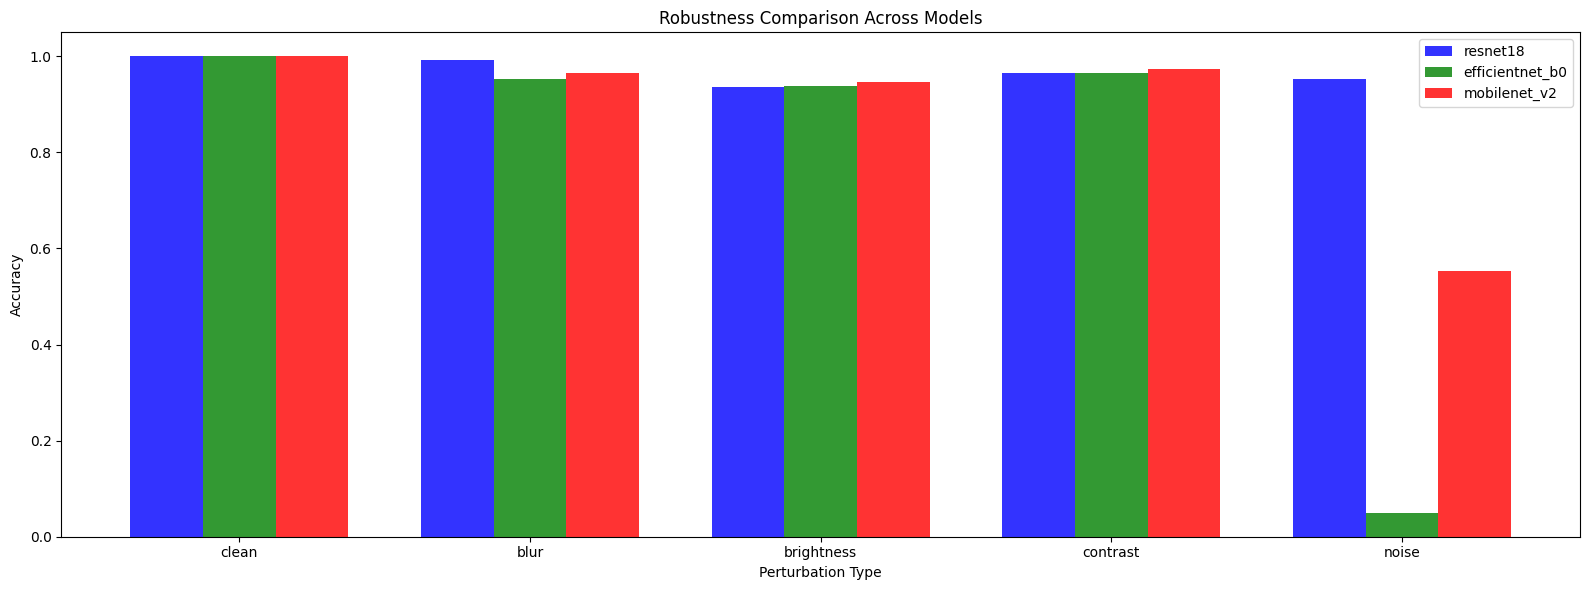

Saved: robustness_plot.png


In [27]:
def plot_robustness(robustness_results):
    perturbations = ["clean", "blur", "brightness", "contrast", "noise"]
    model_names = list(robustness_results.keys())
    colors = {"resnet18": "blue", "efficientnet_b0": "green", "mobilenet_v2": "red"}
    x = np.arange(len(perturbations))
    width = 0.25
    fig, ax = plt.subplots(figsize=(16, 6))
    for i, name in enumerate(model_names):
        accs = [robustness_results[name][p]["acc"] for p in perturbations]
        ax.bar(x + i * width, accs, width, label=name, color=colors.get(name, "gray"), alpha=0.8)
    ax.set_xlabel("Perturbation Type")
    ax.set_ylabel("Accuracy")
    ax.set_title("Robustness Comparison Across Models")
    ax.set_xticks(x + width)
    ax.set_xticklabels(perturbations)
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "robustness_plot.png"), dpi=150)
    plt.show()
    print("Saved: robustness_plot.png")

plot_robustness(robustness_results)

## 20) Segmentation Preprocessing

In [20]:
from rembg import remove as rembg_remove, new_session

# Uses GPU session for much faster processing
session = new_session("u2net", providers=["CUDAExecutionProvider"])

def segment_and_save(src_root, dst_root, letters):
    for L in letters:
        src_dir = os.path.join(src_root, L)
        dst_dir = os.path.join(dst_root, L)
        os.makedirs(dst_dir, exist_ok=True)

        images = list_images(src_dir)
        print(f"Processing {L}: {len(images)} images...")

        for img_path in tqdm(images, desc=L, leave=False):
            fname = os.path.splitext(os.path.basename(img_path))[0] + ".png"
            dst_path = os.path.join(dst_dir, fname)

            if os.path.exists(dst_path):
                continue

            img = Image.open(img_path).convert("RGB")
            result = rembg_remove(img, session=session)
            result = result.convert("RGB")
            result.save(dst_path)

    print("\nSegmentation complete.")
    print(f"Saved to: {dst_root}")

print("Starting background removal with GPU acceleration...")
print("Safe to interrupt and resume — already processed files are skipped.")
segment_and_save(ALPHABET_ROOT, SEG_ROOT, letters)

Starting background removal with GPU acceleration...
Safe to interrupt and resume — already processed files are skipped.
Processing A: 3000 images...


A:   0%|          | 0/3000 [00:00<?, ?it/s]

Processing B: 3000 images...


B:   0%|          | 0/3000 [00:00<?, ?it/s]

Processing C: 3000 images...


...

Processing Y: 3000 images...


Y:   0%|          | 0/3000 [00:00<?, ?it/s]

Processing Z: 3000 images...


Z:   0%|          | 0/3000 [00:00<?, ?it/s]


Segmentation complete.
Saved to: asl_alphabet_segmented


## 21) Collecting Segmented Samples

In [21]:
def collect_segmented_alphabet_samples(seg_root):
    samples = []
    for L in letters:
        cdir = os.path.join(seg_root, L)
        if not os.path.isdir(cdir):
            raise FileNotFoundError(f"Missing segmented folder: {cdir}")
        for p in list_images(cdir):
            samples.append((p, class_to_idx[L]))
    return samples

seg_alphabet_samples = collect_segmented_alphabet_samples(SEG_ROOT)
seg_all_samples = seg_alphabet_samples + digit_samples

print(f"Segmented alphabet: {len(seg_alphabet_samples)}")
print(f"Digits (unchanged): {len(digit_samples)}")
print(f"Total: {len(seg_all_samples)}")

Segmented alphabet: 78000
Digits (unchanged): 5000
Total: 83000


## 22) Segmented Train/Val/Test Split

In [22]:
seg_ys = np.array([y for _, y in seg_all_samples])

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=SEED)
seg_trainval_idx, seg_test_idx = next(sss1.split(np.zeros(len(seg_ys)), seg_ys))

seg_trainval = [seg_all_samples[i] for i in seg_trainval_idx]
seg_test = [seg_all_samples[i] for i in seg_test_idx]

seg_ys_tv = np.array([y for _, y in seg_trainval])
val_rel = VAL_FRAC / (TRAIN_FRAC + VAL_FRAC)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_rel, random_state=SEED)
seg_tr_idx, seg_val_idx = next(sss2.split(np.zeros(len(seg_ys_tv)), seg_ys_tv))

seg_train = [seg_trainval[i] for i in seg_tr_idx]
seg_val = [seg_trainval[i] for i in seg_val_idx]

print(f"Seg Train: {len(seg_train)}")
print(f"Seg Val: {len(seg_val)}")
print(f"Seg Test: {len(seg_test)}")

Seg Train: 58100
Seg Val: 12450
Seg Test: 12450


## 23) Train Best Model on Segmented Data

In [23]:
print(f"Training {best_model_name} on segmented data...")

seg_history, seg_path = train_model(
    best_model_name,
    seg_train,
    seg_val,
    tag="_segmented"
)

Training resnet18 on segmented data...

Training: resnet18_segmented


[resnet18_segmented] Epoch 01/10 [train]:   0%|          | 0/454 [00:00<?, ?it/s]

[resnet18_segmented] Epoch 01/10 | train_loss=0.3530 | train_acc=0.9253 | val_acc=0.9906 | val_f1=0.9812 | test_acc=0.9378 | test_f1=0.9398 | lr=9.76e-05 | time=498.6s
 New best saved (0.9906)


[resnet18_segmented] Epoch 02/10 [train]:   0%|          | 0/454 [00:00<?, ?it/s]

[resnet18_segmented] Epoch 02/10 | train_loss=0.0491 | train_acc=0.9876 | val_acc=0.9965 | val_f1=0.9970 | test_acc=0.9729 | test_f1=0.9762 | lr=9.05e-05 | time=456.6s
 New best saved (0.9965)


...

[resnet18_segmented] Epoch 08/10 | train_loss=0.0074 | train_acc=0.9978 | val_acc=0.9989 | val_f1=0.9988 | test_acc=0.9897 | test_f1=0.9921 | lr=9.55e-06 | time=474.7s
  No improvement (1/3)


[resnet18_segmented] Epoch 09/10 [train]:   0%|          | 0/454 [00:00<?, ?it/s]

[resnet18_segmented] Epoch 09/10 | train_loss=0.0062 | train_acc=0.9985 | val_acc=0.9991 | val_f1=0.9990 | test_acc=0.9924 | test_f1=0.9942 | lr=2.45e-06 | time=489.7s
  No improvement (2/3)


[resnet18_segmented] Epoch 10/10 [train]:   0%|          | 0/454 [00:00<?, ?it/s]

[resnet18_segmented] Epoch 10/10 | train_loss=0.0051 | train_acc=0.9986 | val_acc=0.9994 | val_f1=0.9992 | test_acc=0.9939 | test_f1=0.9953 | lr=0.00e+00 | time=457.1s
 New best saved (0.9994)

  Completed all 10 epochs

Best val acc for resnet18_segmented: 0.9994
Saved to: runs_asl36_final\best_resnet18_segmented.pt


## 24) Compare Baseline vs Segmented

In [24]:
seg_test_loader = DataLoader(
    ASLDataset(seg_test, test_tf),
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=0,
)

seg_model = build_model(best_model_name)
seg_model.load_state_dict(torch.load(seg_path, map_location=DEVICE, weights_only=True))

seg_acc, seg_f1, _, _ = evaluate(seg_model, seg_test_loader, split_name="seg_test")

print(f"\n{'Model':<30} {'Test Acc':>10} {'Test F1':>10}")
print("-" * 52)
print(f"{'Baseline ' + best_model_name:<30} "f"{test_results[best_model_name]['test_acc']:>10.4f} "f"{test_results[best_model_name]['test_f1']:>10.4f}")
print(f"{'Segmented ' + best_model_name:<30} "f"{seg_acc:>10.4f} "f"{seg_f1:>10.4f}")

 seg_test   → acc=0.9993 | macroF1=0.9994

Model                            Test Acc    Test F1
----------------------------------------------------
Baseline resnet18                  1.0000     1.0000
Segmented resnet18                 0.9993     0.9994


## 25) Robustness: Baseline vs Segmented

In [25]:
print(f"\nRobustness: Baseline vs Segmented ({best_model_name})")
seg_robustness = robustness_test(best_model_name, seg_path, seg_test)

perturbations = ["clean", "blur", "brightness", "contrast", "noise"]
print(f"\n{'Perturbation':<15} {'Baseline Acc':>14} {'Segmented Acc':>14} {'Diff':>8}")
print("-" * 55)
for p in perturbations:
    base_acc  = robustness_results[best_model_name][p]["acc"]
    seg_acc_p = seg_robustness[p]["acc"]
    diff      = seg_acc_p - base_acc
    print(f"{p:<15} {base_acc:>14.4f} {seg_acc_p:>14.4f} {diff:>+8.4f}")

with open(os.path.join(OUT_DIR, "seg_robustness_results.json"), "w") as f:json.dump(seg_robustness, f, indent=2)


Robustness: Baseline vs Segmented (resnet18)
  resnet18                  | clean        | acc=0.9993 | f1=0.9994
  resnet18                  | blur         | acc=0.9639 | f1=0.8956
  resnet18                  | brightness   | acc=0.9934 | f1=0.9947
  resnet18                  | contrast     | acc=0.9918 | f1=0.9920
  resnet18                  | noise        | acc=0.7872 | f1=0.8420

Perturbation      Baseline Acc  Segmented Acc     Diff
-------------------------------------------------------
clean                   1.0000         0.9993  -0.0007
blur                    0.9916         0.9639  -0.0278
brightness              0.9371         0.9934  +0.0563
contrast                0.9651         0.9918  +0.0267
noise                   0.9531         0.7872  -0.1659


## 26) Final Summary Table

In [26]:
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)

print(f"\n{'Model':<30} {'Test Acc':>10} {'Test F1':>10}")
print("-" * 52)
for name in model_paths:
    r = test_results[name]
    print(f"{name:<30} {r['test_acc']:>10.4f} {r['test_f1']:>10.4f}")
print(f"{'Segmented '+best_model_name:<30} {seg_acc:>10.4f} {seg_f1:>10.4f}")

print(f"\n{'Model':<25} {'Clean':>8} {'Blur':>8} {'Bright':>8} {'Contrast':>10} {'Noise':>8}")
print("-" * 70)
for name in model_paths:
    row = robustness_results[name]
    print(f"{name:<25}", end="")
    for p in ["clean", "blur", "brightness", "contrast", "noise"]:
        print(f" {row[p]['acc']:>8.4f}", end="")
    print()

print(f"\n{'Segmented '+best_model_name:<25}", end="")
for p in ["clean", "blur", "brightness", "contrast", "noise"]:
    print(f" {seg_robustness[p]['acc']:>8.4f}", end="")
print()

print("\nAll results saved to:", OUT_DIR)
print("\nFiles saved:")
for f in sorted(os.listdir(OUT_DIR)):
    print(f" {f}")


FINAL RESULTS SUMMARY

Model                            Test Acc    Test F1
----------------------------------------------------
resnet18                           1.0000     1.0000
efficientnet_b0                    0.9999     0.9999
mobilenet_v2                       0.9999     0.9999
Segmented resnet18                 0.9993     0.9994

Model                        Clean     Blur   Bright   Contrast    Noise
----------------------------------------------------------------------
resnet18                    1.0000   0.9916   0.9371   0.9651   0.9531
efficientnet_b0             0.9999   0.9536   0.9391   0.9662   0.0491
mobilenet_v2                0.9999   0.9661   0.9458   0.9735   0.5539

Segmented resnet18          0.9993   0.9639   0.9934   0.9918   0.7872

All results saved to: runs_asl36_final

Files saved:
 best_efficientnet_b0.pt
 best_efficientnet_b0_segmented.pt
 best_mobilenet_v2.pt
 best_resnet18.pt
 best_resnet18_finetuned.pt
 best_resnet18_segmented.pt
 confusion_matrix_